# TP Final — Parte 2
## Preprocesamiento, Feature Engineering y Reducción de Dimensionalidad

**Materia:** Análisis de Datos — CEIA FIUBA (1B 2026)  
**Dataset:** Chicago Crimes 2025

---

### Definición del problema de ML

Se plantea un problema de **clasificación supervisada binaria**: predecir si un crimen resultará en arresto (`Arrest`) a partir del tipo de crimen, ubicación, contexto temporal y atributos auxiliares. La distribución observada en el EDA (~16% arrestos vs. ~84% sin arresto) caracteriza un problema desbalanceado.

## 1. Setup y carga de datos

In [33]:
# Librerías base
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Preprocesamiento y modelado de datos
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA

# Codificación avanzada
from category_encoders import OneHotEncoder, TargetEncoder

# Balance de clases
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)


### Carga del dataset principal y enriquecimiento

Se reutiliza el flujo de la Parte 1: merge del dataset principal con la tabla de códigos **IUCR** (para recuperar `Index Code` y descripciones del delito) y con el dataset de **Community Areas** (para asociar el código numérico a su nombre).

In [34]:
# Dataset principal de crímenes
df = pd.read_csv("Crimes_-_2025_20260312.csv")

# Dataset de Community Areas (nombres de las áreas)
community_areas = pd.read_csv('Boundaries_-_Community_Areas_20260329.csv', usecols=['AREA_NUMBE', 'COMMUNITY'])
community_areas = community_areas.rename(columns={'AREA_NUMBE': 'Community Area', 'COMMUNITY': 'Community Area Description'})
community_areas['Community Area'] = community_areas['Community Area'].astype(int)

# Dataset de códigos IUCR (descripción de delitos)
iucr_codes = pd.read_csv('Chicago_Police_Department_-_Illinois_Uniform_Crime_Reporting_(IUCR)_Codes_20260329.csv')
iucr_codes = iucr_codes.rename(columns={'PRIMARY DESCRIPTION': 'IUCR Primary', 'SECONDARY DESCRIPTION': 'IUCR Secondary', 'INDEX CODE': 'Index Code'})
iucr_codes['IUCR'] = iucr_codes['IUCR'].str.zfill(4)

# Dataset enriquecido: merge único con IUCR y Community Areas
df_chicago = df.merge(iucr_codes[['IUCR', 'IUCR Primary', 'IUCR Secondary', 'Index Code']], on='IUCR', how='left') \
               .merge(community_areas, on='Community Area', how='left')

# Validación: verificar que el merge no duplicó ni perdió filas
print(f"Dataset original:     {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Dataset enriquecido:  {df_chicago.shape[0]} filas, {df_chicago.shape[1]} columnas")
assert df.shape[0] == df_chicago.shape[0], "ERROR: el merge alteró la cantidad de filas"
print("Validación OK: misma cantidad de filas")
df_chicago

Dataset original:     236686 filas, 22 columnas
Dataset enriquecido:  236686 filas, 26 columnas
Validación OK: misma cantidad de filas


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,IUCR Primary,IUCR Secondary,Index Code,Community Area Description
0,14075483,JK105557,12/31/2025 11:58:00 PM,050XX S PAULINA ST,0560,ASSAULT,SIMPLE,RESIDENCE,False,False,931,9,20.0,61.0,08A,1165860.0,1871343.0,2025,01/09/2026 03:40:47 PM,41.802549,-87.667246,POINT (-87.667246428 41.802549018),ASSAULT,SIMPLE,N,NEW CITY
1,14070833,JK100050,12/31/2025 11:55:00 PM,053XX W WASHINGTON BLVD,0930,MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,APARTMENT,False,True,1522,15,37.0,25.0,07,1140809.0,1900235.0,2025,01/08/2026 03:46:48 PM,41.882329,-87.758411,POINT (-87.758411303 41.882328854),MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,I,AUSTIN
2,14070745,JK100011,12/31/2025 11:54:00 PM,100XX W OHARE ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,AIRCRAFT,False,False,1651,16,41.0,76.0,24,1100658.0,1934241.0,2025,01/08/2026 03:46:48 PM,41.976290,-87.905227,POINT (-87.905227221 41.976290414),PUBLIC PEACE VIOLATION,OTHER VIOLATION,N,OHARE
3,14070845,JK100006,12/31/2025 11:54:00 PM,013XX W LAKE ST,0454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",RESTAURANT,True,False,1215,12,27.0,28.0,08B,1167120.0,1901555.0,2025,01/08/2026 03:46:48 PM,41.885427,-87.661759,POINT (-87.661759042 41.885426714),BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",N,NEAR WEST SIDE
4,14070799,JK100014,12/31/2025 11:54:00 PM,100XX W OHARE ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,AIRCRAFT,False,False,1651,16,41.0,76.0,24,1100658.0,1934241.0,2025,01/08/2026 03:46:48 PM,41.976290,-87.905227,POINT (-87.905227221 41.976290414),PUBLIC PEACE VIOLATION,OTHER VIOLATION,N,OHARE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236681,14011867,JJ468702,01/01/2025 12:00:00 AM,122XX S THROOP ST,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,524,5,21.0,53.0,14,1169881.0,1823639.0,2025,11/02/2025 03:41:09 PM,41.671556,-87.653881,POINT (-87.653880899 41.671556077),CRIMINAL DAMAGE,TO PROPERTY,N,WEST PULLMAN
236682,13723166,JJ118245,01/01/2025 12:00:00 AM,035XX N WILTON AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,1924,19,44.0,6.0,14,1169306.0,1923754.0,2025,11/02/2025 03:41:09 PM,41.946295,-87.653085,POINT (-87.653085108 41.946294768),CRIMINAL DAMAGE,TO VEHICLE,N,LAKE VIEW
236683,13762064,JJ165443,01/01/2025 12:00:00 AM,026XX W HIRSCH ST,1365,CRIMINAL TRESPASS,TO RESIDENCE,RESIDENCE,False,False,1423,14,26.0,24.0,26,1158375.0,1909206.0,2025,11/02/2025 03:41:09 PM,41.906605,-87.693663,POINT (-87.693662846 41.906605031),CRIMINAL TRESPASS,TO RESIDENCE,N,WEST TOWN
236684,13924498,JJ362854,01/01/2025 12:00:00 AM,028XX N KILBOURN AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,SCHOOL - PUBLIC GROUNDS,False,False,2521,25,31.0,20.0,14,1145894.0,1918497.0,2025,11/02/2025 03:41:09 PM,41.932347,-87.739275,POINT (-87.739274504 41.932346705),CRIMINAL DAMAGE,TO PROPERTY,N,HERMOSA


---
## 2. Selección de features y limpieza general

Criterios de eliminación de columnas:

| Columna | Motivo |
|---|---|
| `ID`, `Case Number` | Identificadores únicos (unique identifier / RD Number), sin aporte predictivo. |
| `Year` | Constante (todo 2025 en este corte). |
| `Location` | Tipo `Point`, derivado de `Latitude` + `Longitude`. |
| `Updated On` | Timestamp administrativo de cuándo se actualizó el registro, no cuándo ocurrió el hecho. |
| `Block` | Dirección redactada, alta cardinalidad, reemplazable por `Beat` / `District`. |
| `X Coordinate`, `Y Coordinate` | Misma ubicación que `Latitude` / `Longitude` pero proyectadas en **State Plane Illinois East NAD 1983**. Conservamos lat/lon (grados decimales, más interpretable). |
| `Location Description` | Alta cardinalidad (130 valores de texto libre). La ubicación ya queda representada por `Latitude`, `Longitude`, `Beat`, `District`, `Ward` y `Community Area`. |
| `Description` | Subcategoría fina del crimen con 316 valores únicos (texto libre). Información ya cubierta por `Primary Type` + `FBI Code`; codificarla agregaría una explosión de categorías sin aporte claro. |
| `Community Area Description` | Es el nombre textual del *Community Area* (ej. "AUSTIN", "ENGLEWOOD"). No aporta información predictiva adicional al código numérico `Community Area`|
| `IUCR` | Código numérico del tipo de crimen. Como feature es redundante: mapea 1-a-1 con la combinación `Primary Type` + `Description`. |
| `IUCR Primary` | Aportado por el merge con la tabla IUCR. Es **idéntico** a `Primary Type` del dataset original → redundante. |
| `IUCR Secondary` | Aportado por el merge con la tabla IUCR. Es **idéntico** a `Description` del dataset original → redundante. |
| `Index Code` | Aportado por el merge con la tabla IUCR. ~4% de valores faltantes y señal marginal (sólo indica si el crimen es un *Index Offense* del FBI, información ya contenida implícitamente en `Primary Type` + `FBI Code`). |


También convertimos `Date` a `datetime`, estandarizamos los strings categóricos y chequeamos duplicados.

> **Nota sobre `Date`.** El diccionario oficial aclara que este campo *"is sometimes a best estimate"* — conviene no tratarlo como timestamp exacto, aunque sí como indicador aproximado.


In [35]:
# Columnas a eliminar:
# - Identificadores, constantes o derivadas.
# - X/Y Coordinate: redundantes con Latitude/Longitude (proyección State Plane Illinois East NAD 1983).
# - Location Description: alta cardinalidad, ubicación ya cubierta por Lat/Lon, Beat, District, Ward, Community Area.
# - Description: subcategoría fina del crimen con ~380 valores, redundante con Primary Type + FBI Code.
# - Community Area Description: nombre textual de la Community Area, redundante con el código numérico.
# - IUCR: código del tipo de crimen usado solo como clave de merge; redundante con Primary Type + Description.
# - IUCR Primary: idéntico a 'Primary Type' (mismo campo, nombres distintos).
# - IUCR Secondary: idéntico a 'Description' (mismo campo, nombres distintos).
# - Index Code: del merge IUCR, ~4% de faltantes y señal marginal.
cols_drop = [
    'ID', 'Case Number', 'Year', 'Location', 'Updated On', 'Block',
    'X Coordinate', 'Y Coordinate',
    'Location Description', 'Description', 'Community Area Description',
    'IUCR', 'IUCR Primary', 'IUCR Secondary', 'Index Code',
]
df_clean = df_chicago.drop(columns=cols_drop)

# Parseo de fechas
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df_clean.head()

,Date,Primary Type,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,Latitude,Longitude
0,2025-12-31 23:58:00,ASSAULT,False,False,931,9,20.0,61.0,08A,41.802549,-87.667246
1,2025-12-31 23:55:00,MOTOR VEHICLE THEFT,False,True,1522,15,37.0,25.0,07,41.882329,-87.758411
2,2025-12-31 23:54:00,PUBLIC PEACE VIOLATION,False,False,1651,16,41.0,76.0,24,41.976290,-87.905227
3,2025-12-31 23:54:00,BATTERY,True,False,1215,12,27.0,28.0,08B,41.885427,-87.661759
4,2025-12-31 23:54:00,PUBLIC PEACE VIOLATION,False,False,1651,16,41.0,76.0,24,41.976290,-87.905227


In [36]:
# Limpieza básica de strings
# 1. Pasa todos los None a np.nan
# 2. Fuerza tipo string
# 3. Eliminar espacios al principio y fin
# 4. Pasa todo a mayusculas 
for col in ['Primary Type', 'FBI Code']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].where(df_clean[col].notna(), np.nan)
        mask = df_clean[col].notna()
        df_clean.loc[mask, col] = df_clean.loc[mask, col].astype(str).str.strip().str.upper()

df_clean.head()


,Date,Primary Type,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,Latitude,Longitude
0,2025-12-31 23:58:00,ASSAULT,False,False,931,9,20.0,61.0,08A,41.802549,-87.667246
1,2025-12-31 23:55:00,MOTOR VEHICLE THEFT,False,True,1522,15,37.0,25.0,07,41.882329,-87.758411
2,2025-12-31 23:54:00,PUBLIC PEACE VIOLATION,False,False,1651,16,41.0,76.0,24,41.976290,-87.905227
3,2025-12-31 23:54:00,BATTERY,True,False,1215,12,27.0,28.0,08B,41.885427,-87.661759
4,2025-12-31 23:54:00,PUBLIC PEACE VIOLATION,False,False,1651,16,41.0,76.0,24,41.976290,-87.905227


In [37]:
# Duplicados (por registro completo pues los IDs ya fueron eliminados)
dups = df_clean.duplicated().sum()
print(f'Filas duplicadas: {dups}')
if dups > 0:
    # Muestra las primeras 10 filas involucradas en duplicados (todas las copias)
    print('\nEjemplos de duplicados:')
    display(df_clean[df_clean.duplicated(keep=False)]
            .sort_values(list(df_clean.columns))
            .head(10))
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)

Filas duplicadas: 740

Ejemplos de duplicados:


,Date,Primary Type,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,Latitude,Longitude
235565,2025-01-02 12:15:00,NARCOTICS,True,False,1134,11,24.0,29.0,18,41.868181,-87.709271
235566,2025-01-02 12:15:00,NARCOTICS,True,False,1134,11,24.0,29.0,18,41.868181,-87.709271
234050,2025-01-04 22:55:00,NARCOTICS,True,False,2513,25,29.0,25.0,18,41.914612,-87.784208
234051,2025-01-04 22:55:00,NARCOTICS,True,False,2513,25,29.0,25.0,18,41.914612,-87.784208
233556,2025-01-05 19:00:00,THEFT,False,False,1935,19,43.0,7.0,06,41.930906,-87.644017
233567,2025-01-05 19:00:00,THEFT,False,False,1935,19,43.0,7.0,06,41.930906,-87.644017
233355,2025-01-06 03:53:00,BURGLARY,False,False,912,9,12.0,59.0,05,41.835773,-87.665695
233356,2025-01-06 03:53:00,BURGLARY,False,False,912,9,12.0,59.0,05,41.835773,-87.665695
233267,2025-01-06 09:00:00,THEFT,False,False,925,9,11.0,61.0,06,41.823560,-87.637715
233270,2025-01-06 09:00:00,THEFT,False,False,925,9,11.0,61.0,06,41.823560,-87.637715


In [38]:
# Eliminación de filas con faltantes en códigos geográficos.
# 'Community Area' y 'Ward' (1 fila) presenta en total 3 registros faltantes sobre ~236k. 
# Dado el volumen ínfimo optamos por eliminar esas filas en vez de imputar.
geo_required = ['Community Area', 'Ward']
n_drop_geo = df_clean[geo_required].isna().any(axis=1).sum()
print(f'\nFilas con faltantes en {geo_required}: {n_drop_geo} → eliminadas')
df_clean = df_clean.dropna(subset=geo_required).reset_index(drop=True)

print(f'\nForma tras limpieza: {df_clean.shape}')
df_clean.dtypes


Filas con faltantes en ['Community Area', 'Ward']: 3 → eliminadas

Forma tras limpieza: (235943, 11)


Date              datetime64[ns]
Primary Type              object
Arrest                      bool
Domestic                    bool
Beat                       int64
District                   int64
Ward                     float64
Community Area           float64
FBI Code                  object
Latitude                 float64
Longitude                float64
dtype: object

---
## 3. Split train / test (stratify)

El split se realiza **antes** de cualquier imputación, codificación o escalado. Esto evita **data leakage**: si estimáramos medias, modas o categorías usando observaciones del test, la evaluación posterior quedaría contaminada.

Además se usa `stratify=y` porque la clase positiva (`Arrest=True`) ronda el 16%; un split aleatorio simple podría producir generar splits con proporciones distintas.

In [39]:
y = df_clean['Arrest'].astype(int)
X = df_clean.drop(columns=['Arrest'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print('\nProporción de clases en train:')
print(y_train.value_counts(normalize=True).round(4))
print('\nProporción de clases en test:')
print(y_test.value_counts(normalize=True).round(4))


X_train: (188754, 10) | X_test: (47189, 10)

Proporción de clases en train:
Arrest
0    0.8401
1    0.1599
Name: proportion, dtype: float64

Proporción de clases en test:
Arrest
0    0.8401
1    0.1599
Name: proportion, dtype: float64


---
## 4. Tratamiento de valores faltantes

Diagnóstico inicial sobre el conjunto de entrenamiento.

In [40]:
missing_pct = X_train.isna().mean().sort_values(ascending=False) * 100
missing_pct[missing_pct > 0].round(3).to_frame('% faltante')


,% faltante
Latitude,0.037
Longitude,0.037


**Estrategia por tipo de variable:**

- **Coordenadas** (`Latitude`, `Longitude`): 0.04% faltante, patrón MAR. Se imputan con la **mediana** para no mover el centroide geográfico.
- **Códigos geográficos** (`Community Area`: 3 faltantes, `Ward`: 1 faltante — 3 registros únicos totales según el EDA): se **eliminan las filas** en la limpieza general.

Las demás variables categóricas (`Primary Type`, `FBI Code`, `Beat`, `District`) no presentan faltantes tras la limpieza general (ver EDA), por lo que no requieren imputación.

In [41]:
num_coords = ['Latitude', 'Longitude']

imp_median = SimpleImputer(strategy='median')

X_train[num_coords] = imp_median.fit_transform(X_train[num_coords])
X_test[num_coords]  = imp_median.transform(X_test[num_coords])

assert X_train[num_coords].isna().sum().sum() == 0
assert X_test[num_coords].isna().sum().sum() == 0
print('Imputación completada. Faltantes restantes (por columna):')
print(X_train.isna().sum()[X_train.isna().sum() > 0])


Imputación completada. Faltantes restantes (por columna):
Series([], dtype: int64)


---
## 5. Feature engineering

Se crean nuevas features derivadas de `Date`, de las coordenadas y de `Primary Type`.

- Temporales (`Date`): `hour`, `day_of_week`, `month`, `quarter`, `day_of_year`, `is_night`
- Geográfica: `distancia_cbd` — distancia de Haversine (km) al Loop de Chicago (41.8827, -87.6227). Captura el gradiente urbano centro-periferia.
- Tipología del crimen: `is_violent` (flag de crimen violento) y `night_violent` (interacción binaria `is_night × is_violent`).

In [42]:
def build_time_features(df_):
    out = df_.copy()
    d = out['Date']
    out['hour']         = d.dt.hour
    out['day_of_week']  = d.dt.dayofweek
    out['month']        = d.dt.month
    out['quarter']      = d.dt.quarter
    out['day_of_year']  = d.dt.dayofyear
    out['is_night']    = ((out['hour'] >= 22) | (out['hour'] < 6)).astype(int)
    return out

X_train = build_time_features(X_train)
X_test  = build_time_features(X_test)

X_train[['hour', 'day_of_week', 'month', 'quarter', 'day_of_year', 'is_night']].head()


,hour,day_of_week,month,quarter,day_of_year,is_night
26773,0,5,11,4,319,1
62977,1,6,9,3,264,1
93883,10,2,8,3,218,0
113426,11,3,7,3,191,0
235208,17,2,1,1,1,0


In [43]:
# Descartamos Date, porque ya tenemos las nuevas features
X_train = X_train.drop(columns=['Date'])
X_test  = X_test.drop(columns=['Date'])

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
X_train.head(3)


X_train: (188754, 15) | X_test: (47189, 15)


,Primary Type,Domestic,Beat,District,Ward,Community Area,FBI Code,Latitude,Longitude,hour,day_of_week,month,quarter,day_of_year,is_night
26773,BATTERY,False,1654,16,41.0,76.0,08B,41.956736,-87.890935,0,5,11,4,319,1
62977,MOTOR VEHICLE THEFT,False,632,6,8.0,44.0,07,41.735747,-87.603948,1,6,9,3,264,1
93883,OTHER OFFENSE,True,1614,16,41.0,76.0,26,41.972999,-87.846513,10,2,8,3,218,0


#### Nueva feature distancia desde cada crimen al centro de Chicago

distancia_cbd — train | min: 0.14 km | max: 28.70 km | media: 10.75 km
distancia_cbd — test  | min: 0.14 km | max: 28.69 km | media: 10.75 km


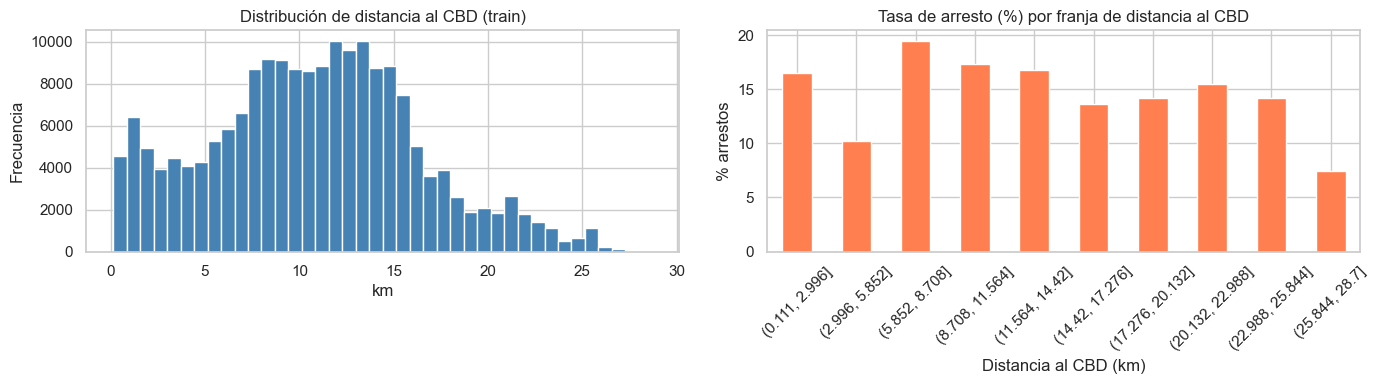

In [ ]:
# ─────────────────────────────────────────────────────────────
# FEATURE: distancia_cbd
# Distancia de Haversine desde cada crimen al Loop de Chicago
# (lat 41.8827, lon -87.6227). Captura el gradiente urbano
# centro-periferia que correlaciona con tipo de crimen y arrestos.
# ─────────────────────────────────────────────────────────────

CBD_LAT, CBD_LON = 41.8827, -87.6227

def haversine_km(lat, lon, ref_lat=CBD_LAT, ref_lon=CBD_LON):
    """Distancia en km entre cada punto (lat, lon) y un punto de referencia."""
    R = 6371.0  # radio terrestre en km
    lat_r  = np.radians(lat)
    lon_r  = np.radians(lon)
    rlat_r = np.radians(ref_lat)
    rlon_r = np.radians(ref_lon)

    dlat = lat_r - rlat_r
    dlon = lon_r - rlon_r

    a = np.sin(dlat / 2) ** 2 + np.cos(rlat_r) * np.cos(lat_r) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

X_train['distancia_cbd'] = haversine_km(X_train['Latitude'].values, X_train['Longitude'].values)
X_test['distancia_cbd']  = haversine_km(X_test['Latitude'].values,  X_test['Longitude'].values)

# Validación rápida
print(f"distancia_cbd — train | min: {X_train['distancia_cbd'].min():.2f} km | "
      f"max: {X_train['distancia_cbd'].max():.2f} km | "
      f"media: {X_train['distancia_cbd'].mean():.2f} km")
print(f"distancia_cbd — test  | min: {X_test['distancia_cbd'].min():.2f} km | "
      f"max: {X_test['distancia_cbd'].max():.2f} km | "
      f"media: {X_test['distancia_cbd'].mean():.2f} km")

# Distribución vs tasa de arresto (binned)
tmp = X_train[['distancia_cbd']].copy()
tmp['Arrest'] = y_train.values
tmp['dist_bin'] = pd.cut(tmp['distancia_cbd'], bins=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

tmp['distancia_cbd'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de distancia al CBD (train)')
axes[0].set_xlabel('km')
axes[0].set_ylabel('Frecuencia')

arrest_rate = tmp.groupby('dist_bin', observed=True)['Arrest'].mean() * 100
arrest_rate.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Tasa de arresto (%) por franja de distancia al CBD')
axes[1].set_xlabel('Distancia al CBD (km)')
axes[1].set_ylabel('% arrestos')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Nueva feature interaccion binaria entre noche y crimen violento

                         n  tasa_arresto  pct_del_total
combo                                                  
Noche / Violento     16575         18.58            8.8
Día / No violento    95728         17.31           50.7
Día / Violento       41023         14.88           21.7
Noche / No violento  35428         12.50           18.8


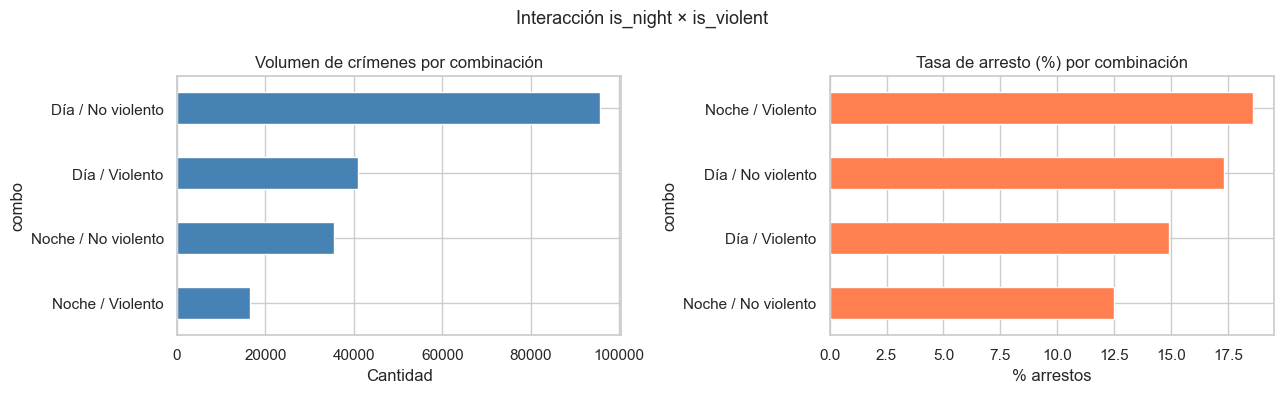

In [45]:
# ─────────────────────────────────────────────────────────────
# FEATURE: night_violent
# Interacción binaria is_night × is_violent.
# Un crimen violento nocturno tiene un perfil operativo distinto
# (menor visibilidad, menor presencia de testigos, respuesta
# policial diferente) que ninguna de las dos flags captura sola.
# ─────────────────────────────────────────────────────────────


VIOLENT  = {'HOMICIDE', 'ASSAULT', 'BATTERY', 'ROBBERY', 'CRIM SEXUAL ASSAULT',
            'CRIMINAL SEXUAL ASSAULT', 'KIDNAPPING'}
PROPERTY = {'THEFT', 'BURGLARY', 'MOTOR VEHICLE THEFT', 'ARSON',
            'CRIMINAL DAMAGE', 'CRIMINAL TRESPASS'}

X_train['is_violent']  = X_train['Primary Type'].isin(VIOLENT).astype(int)
X_test['is_violent']   = X_test['Primary Type'].isin(VIOLENT).astype(int)

X_train['night_violent'] = (X_train['is_night'] * X_train['is_violent']).astype(int)
X_test['night_violent']  = (X_test['is_night']  * X_test['is_violent']).astype(int)

# Distribución de las 4 combinaciones posibles
combos_train = (
    X_train[['is_night', 'is_violent', 'night_violent']]
    .assign(Arrest=y_train.values)
    .assign(combo=lambda d:
        d['is_night'].map({0: 'Día', 1: 'Noche'}) + ' / ' +
        d['is_violent'].map({0: 'No violento', 1: 'Violento'})
    )
)

conteo   = combos_train.groupby('combo').size().rename('n')
arr_rate = combos_train.groupby('combo')['Arrest'].mean().rename('tasa_arresto') * 100
resumen_combos = pd.concat([conteo, arr_rate], axis=1).sort_values('tasa_arresto', ascending=False)
resumen_combos['pct_del_total'] = (resumen_combos['n'] / resumen_combos['n'].sum() * 100).round(1)
print(resumen_combos.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

resumen_combos['n'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Volumen de crímenes por combinación')
axes[0].set_xlabel('Cantidad')

resumen_combos['tasa_arresto'].sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Tasa de arresto (%) por combinación')
axes[1].set_xlabel('% arrestos')

plt.suptitle('Interacción is_night × is_violent', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Codificación de variables categóricas

Estrategia por cardinalidad:

| Variable | Cardinalidad | Técnica | Motivo |
|---|---|---|---|
| `Domestic` | 2 | cast a int | Booleano |
| `Primary Type`, `FBI Code` | baja (~20-35) | `OneHotEncoder` | Preservar interpretabilidad |
| `Beat`, `Community Area`, `Ward` | alta (>50) | `TargetEncoder` | Evitar muchas nuevas features |


In [46]:
# Domestic booleano
X_train['Domestic'] = X_train['Domestic'].astype(int)
X_test['Domestic']  = X_test['Domestic'].astype(int)

# Check de cardinalidad — valida la asignación de técnica de codificación.
cat_cols = ['Primary Type', 'FBI Code', 'Beat', 'Community Area', 'Ward']
card = pd.Series(
    {c: X_train[c].nunique(dropna=False) for c in cat_cols},
    name='cardinalidad'
).sort_values()
print('Cardinalidad de variables categóricas (en train):')
print(card)


Cardinalidad de variables categóricas (en train):
FBI Code           25
Primary Type       31
Ward               50
Community Area     77
Beat              274
Name: cardinalidad, dtype: int64


In [47]:
# One-Hot Encoding de baja cardinalidad
cat_ohe = ['Primary Type', 'FBI Code']
ohe = OneHotEncoder(cols=cat_ohe, use_cat_names=True, handle_unknown='value', handle_missing='value')
X_train = ohe.fit_transform(X_train)
X_test  = ohe.transform(X_test)

print(f'Tras OHE — X_train: {X_train.shape} | X_test: {X_test.shape}')


Tras OHE — X_train: (188754, 72) | X_test: (47189, 72)


In [48]:
# Target Encoding de alta cardinalidad (fit con y_train).
cat_te = ['Beat', 'Community Area', 'Ward']
te = TargetEncoder(cols=cat_te, smoothing=10.0)
X_train = te.fit_transform(X_train, y_train)
X_test  = te.transform(X_test)

print(f'Tras Target Encoding — X_train: {X_train.shape} | X_test: {X_test.shape}')
X_train[cat_te].describe().round(4)


Tras Target Encoding — X_train: (188754, 72) | X_test: (47189, 72)


,Beat,Community Area,Ward
count,188754.0000,188754.0000,188754.0000
mean,0.1599,0.1599,0.1599
std,0.0718,0.0554,0.0426
min,0.0382,0.0577,0.0644
25%,0.1176,0.1240,0.1339
50%,0.1494,0.1458,0.1559
75%,0.1817,0.1843,0.1807
max,0.4692,0.3158,0.2939


In [49]:
X_train.head()

,Primary Type_BATTERY,Primary Type_MOTOR VEHICLE THEFT,Primary Type_OTHER OFFENSE,Primary Type_DECEPTIVE PRACTICE,Primary Type_BURGLARY,Primary Type_CRIMINAL TRESPASS,Primary Type_WEAPONS VIOLATION,Primary Type_ASSAULT,Primary Type_CRIMINAL DAMAGE,Primary Type_ROBBERY,Primary Type_THEFT,Primary Type_INTERFERENCE WITH PUBLIC OFFICER,Primary Type_SEX OFFENSE,Primary Type_NARCOTICS,Primary Type_OFFENSE INVOLVING CHILDREN,Primary Type_ARSON,Primary Type_CONCEALED CARRY LICENSE VIOLATION,Primary Type_HUMAN TRAFFICKING,Primary Type_CRIMINAL SEXUAL ASSAULT,Primary Type_PROSTITUTION,Primary Type_STALKING,Primary Type_INTIMIDATION,Primary Type_LIQUOR LAW VIOLATION,Primary Type_PUBLIC PEACE VIOLATION,Primary Type_HOMICIDE,Primary Type_KIDNAPPING,Primary Type_GAMBLING,Primary Type_OBSCENITY,Primary Type_OTHER NARCOTIC VIOLATION,Primary Type_PUBLIC INDECENCY,...,FBI Code_04B,FBI Code_08A,FBI Code_14,FBI Code_04A,FBI Code_03,FBI Code_06,FBI Code_24,FBI Code_17,FBI Code_18,FBI Code_20,FBI Code_09,FBI Code_10,FBI Code_02,FBI Code_16,FBI Code_22,FBI Code_01A,FBI Code_13,FBI Code_19,FBI Code_12,Latitude,Longitude,hour,day_of_week,month,quarter,day_of_year,is_night,distancia_cbd,is_violent,night_violent
26773,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41.956736,-87.890935,0,5,11,4,319,1,23.670937,1,1
62977,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41.735747,-87.603948,1,6,9,3,264,1,16.414157,0,0
93883,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41.972999,-87.846513,10,2,8,3,218,0,21.062824,0,0
113426,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41.887398,-87.666127,11,3,7,3,191,0,3.632777,0,0
235208,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41.766687,-87.569790,17,2,1,1,1,0,13.624736,0,0


---
## 7. Escalado / normalización

Aplicamos **`StandardScaler`** (media 0, std 1) sobre las features numéricas continuas. Este escalado es necesario para algoritmos sensibles a la escala como PCA y para SMOTE, que calcula distancias entre vecinos.

Las variables categóricas ya transformadas (OHE, target-encoded) no se re-escalan.

In [ ]:
# Features numéricas a escalar. Categóricas codificadas (OHE, target-encoded) NO se re-escalan.
# NOTA: Beat, Community Area y Ward fueron transformadas in-place por TargetEncoder, por lo que ya son numéricas en [0, 1] aproximadamente.
# NOTA 2: is_violent, night_violent y Domestic son binarias 0/1 y no se estandarizan (mismo criterio que las columnas OHE).
num_scale = [
    # Geográficas continuas
    'Latitude', 'Longitude',
    'distancia_cbd',
    # Códigos geográficos target-encoded (ya son numéricos post-TE)
    'Beat', 'Community Area', 'Ward',
    # Códigos geográficos restantes (no target-encoded, pero numéricos)
    'District',
    # Temporales
    'hour', 'day_of_week', 'month', 'quarter', 'day_of_year',
]

# Verificación de no-duplicados y existencia
assert len(num_scale) == len(set(num_scale)), 'num_scale tiene columnas duplicadas'
num_scale = [c for c in num_scale if c in X_train.columns]

In [51]:
# Versión estandarizada
std_scaler = StandardScaler()
X_train_std = X_train.copy()
X_test_std  = X_test.copy()
X_train_std[num_scale] = std_scaler.fit_transform(X_train[num_scale])
X_test_std[num_scale]  = std_scaler.transform(X_test[num_scale])

X_train_std[num_scale].describe().loc[['mean', 'std', 'min', 'max']].round(3).T.head(10)

,mean,std,min,max
Latitude,0.0,1.0,-2.330,2.046
Longitude,0.0,1.0,-4.455,2.417
distancia_cbd,0.0,1.0,-1.900,3.213
Beat,0.0,1.0,-1.694,4.306
Community Area,-0.0,1.0,-1.847,2.816
Ward,-0.0,1.0,-2.240,3.141
District,0.0,1.0,-1.444,2.797
hour,-0.0,1.0,-1.834,1.541
day_of_week,-0.0,1.0,-1.509,1.496
month,0.0,1.0,-1.657,1.636


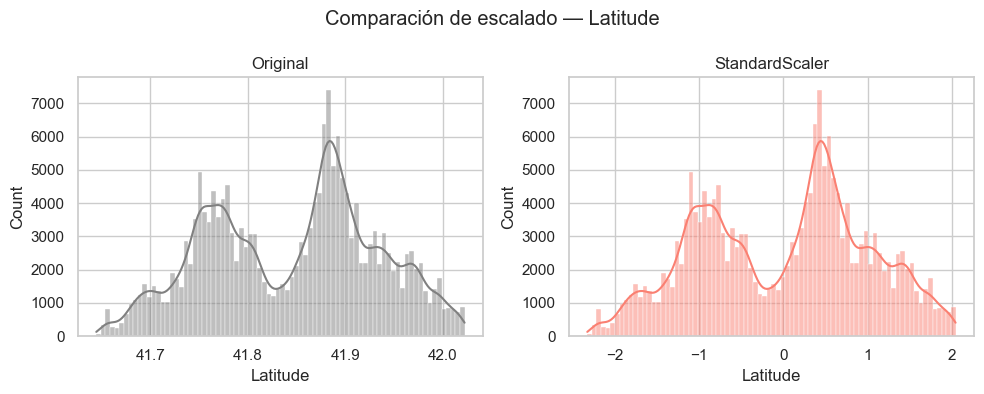

In [52]:
# Visualización comparativa sobre una variable representativa
col = 'Latitude'
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(X_train[col],     kde=True, ax=axes[0], color='gray');   axes[0].set_title('Original')
sns.histplot(X_train_std[col], kde=True, ax=axes[1], color='salmon'); axes[1].set_title('StandardScaler')
plt.suptitle(f'Comparación de escalado — {col}')
plt.tight_layout()
plt.show()


---
## 8. Balanceo de clases

El target `Arrest` ronda el 16% positivo. Bajo este desbalance, un modelo trivial que prediga siempre `False` alcanzaría un alto accuracy, lo que torna esa métrica poco informativa y motiva aplicar un **mecanismo de balanceo**.

**Técnica elegida:** Oversampling con SMOTE, ya que recrea en forma sintética muestras para la clase minoritaria

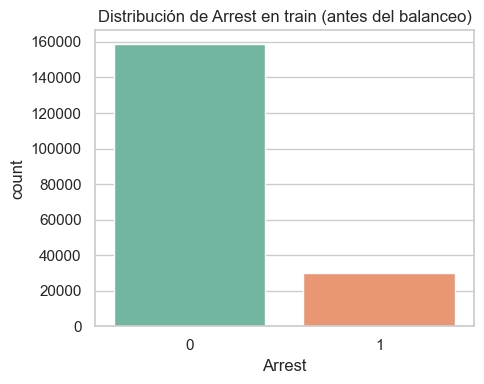

Arrest
0    0.8401
1    0.1599
Name: proportion, dtype: float64


In [53]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=y_train, hue=y_train, palette='Set2', ax=ax, legend=False)
ax.set_title('Distribución de Arrest en train (antes del balanceo)')
ax.set_xlabel('Arrest')
plt.tight_layout()
plt.show()

print(y_train.value_counts(normalize=True).round(4))


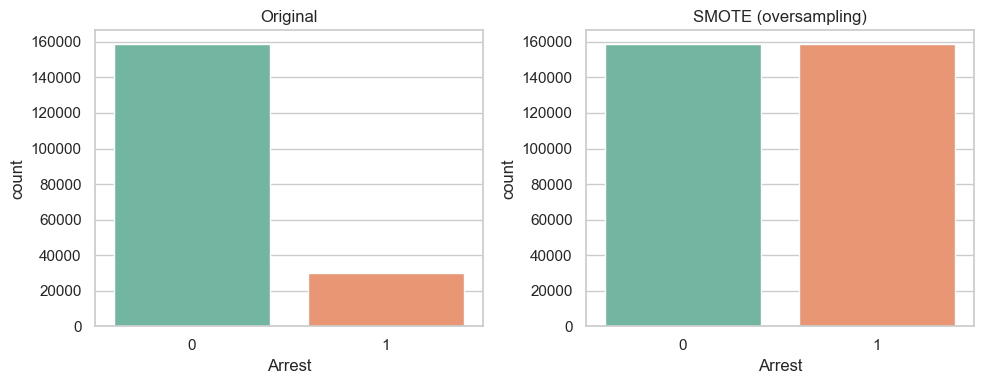

Antes  → {0: 158570, 1: 30184}
SMOTE  → {0: 158570, 1: 158570}


In [54]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_std, y_train)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x=y_train,     hue=y_train,     palette='Set2', ax=axes[0], legend=False)
sns.countplot(x=y_train_bal, hue=y_train_bal, palette='Set2', ax=axes[1], legend=False)
axes[0].set_title('Original')
axes[1].set_title('SMOTE (oversampling)')
plt.tight_layout()
plt.show()

print(f'Antes  → {dict(y_train.value_counts())}')
print(f'SMOTE  → {dict(pd.Series(y_train_bal).value_counts())}')


---
## 9. Selección de features con filtros

Se evalúan dos filtros complementarios:

1. **Correlación entre features** (Pearson, Spearman, Kendall) para detectar **redundancia** entre predictores.
2. **`SelectKBest` con `mutual_info_classif`** para rankear las features por su **información mutua con el target `Arrest`**. La información mutua mide cuánto se reduce la incertidumbre sobre `y` al conocer una feature

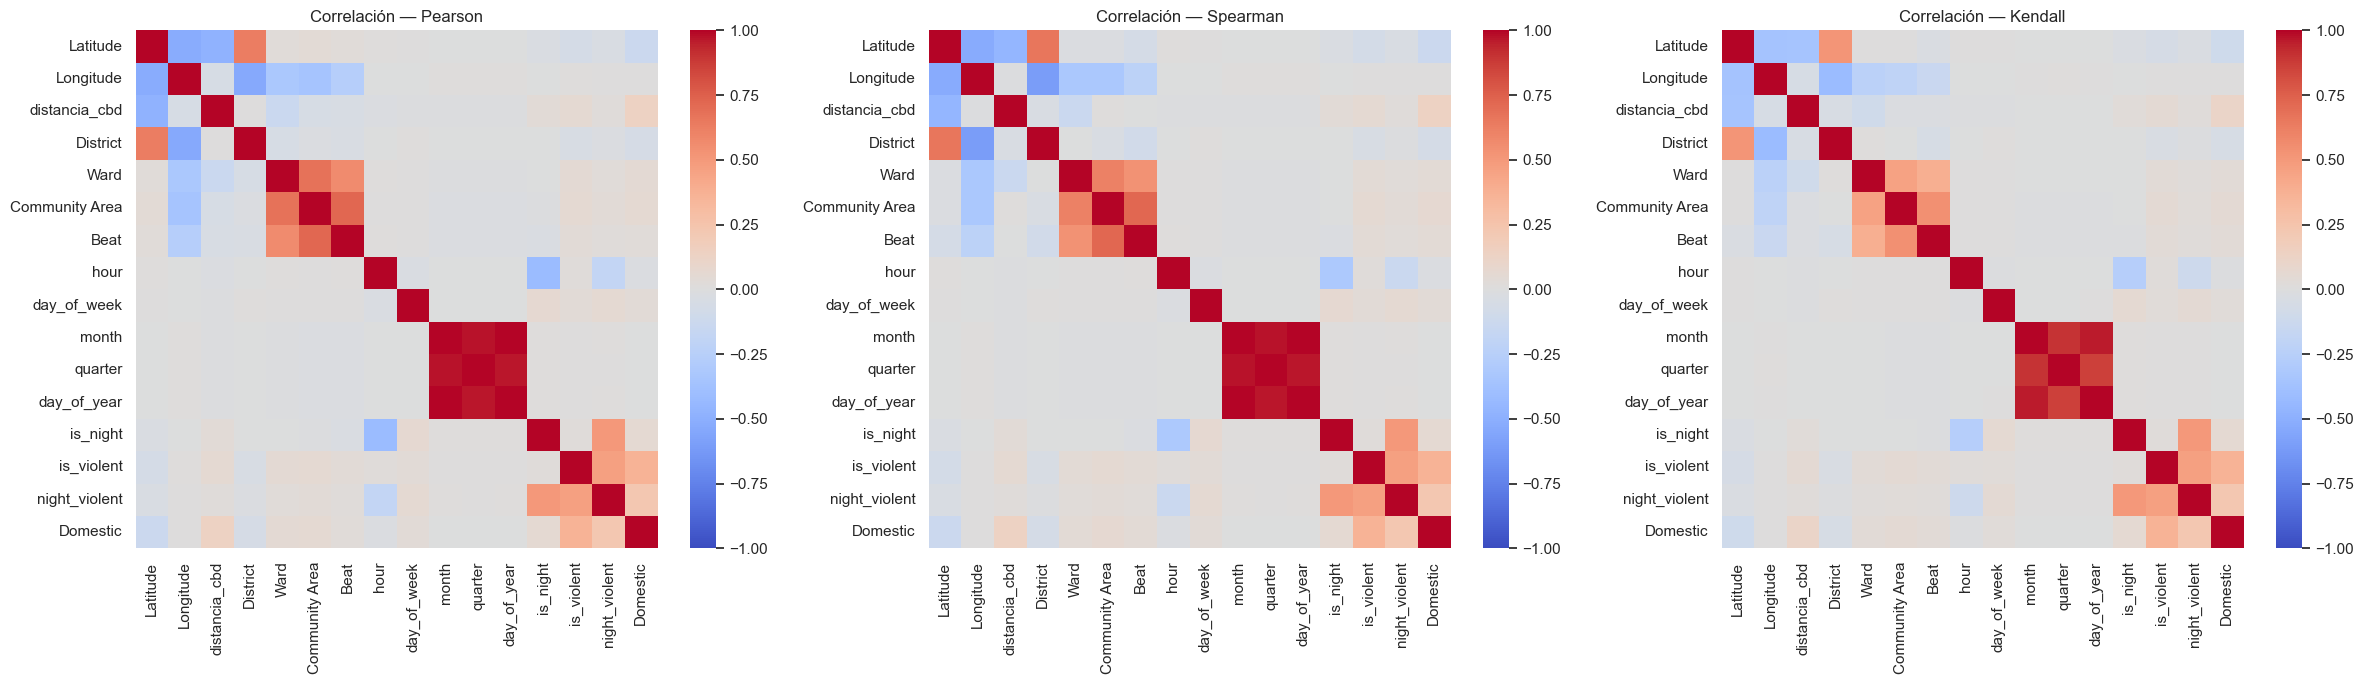

In [55]:
# Heatmap de correlaciones — muestreamos para que sea legible
sample_cols = [
    'Latitude', 'Longitude', 'distancia_cbd',
    'District', 'Ward', 'Community Area', 'Beat',
    'hour', 'day_of_week', 'month', 'quarter', 'day_of_year',
    'is_night', 'is_violent', 'night_violent',
    'Domestic',
]
sample_cols = [c for c in sample_cols if c in X_train_std.columns]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, method in zip(axes, ['pearson', 'spearman', 'kendall']):
    corr = X_train_std[sample_cols].corr(method=method)
    sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(f'Correlación — {method.capitalize()}')
plt.tight_layout()
plt.show()

In [56]:
# Pares con |corr| alta (Pearson), como señal de redundancia
corr_p = X_train_std[sample_cols].corr().abs()
pairs = (
    corr_p.where(np.triu(np.ones(corr_p.shape, dtype=bool), k=1))
          .stack().sort_values(ascending=False)
)
pairs[pairs > 0.9].head(15)


month    day_of_year    0.996236
         quarter        0.969287
quarter  day_of_year    0.965762
dtype: float64

In [57]:
# Pares con |corr| alta (Spearman), como señal de redundancia monótona no-lineal
corr_s = X_train_std[sample_cols].corr(method='spearman').abs()
pairs_s = (
    corr_s.where(np.triu(np.ones(corr_s.shape, dtype=bool), k=1))
          .stack().sort_values(ascending=False)
)
pairs_s[pairs_s > 0.9].head(15)


month    day_of_year    0.996448
         quarter        0.971328
quarter  day_of_year    0.967878
dtype: float64

In [58]:
# Pares con |corr| alta (Kendall), robusto a outliers y tamaños de muestra pequeños
corr_k = X_train_std[sample_cols].corr(method='kendall').abs()
pairs_k = (
    corr_k.where(np.triu(np.ones(corr_k.shape, dtype=bool), k=1))
          .stack().sort_values(ascending=False)
)
pairs_k[pairs_k > 0.9].head(15)


month  day_of_year    0.958431
       quarter        0.904267
dtype: float64

In [59]:
# SelectKBest con mutual_info_classif — ranking por información mutua con el target.
num_cols_std = X_train_std.select_dtypes(include=[np.number]).columns.tolist()
X_tr_num = X_train_std[num_cols_std].fillna(0)

K = 20

sel_mi = SelectKBest(score_func=mutual_info_classif, k=K).fit(X_tr_num, y_train)

ranking = (
    pd.Series(sel_mi.scores_, index=X_tr_num.columns, name='mutual_info')
      .sort_values(ascending=False)
)

features_kbest = ranking.head(K).index.tolist()
print(f'Top-{K} features por información mutua:')
display(ranking.head(K).round(4).to_frame())

# APLICAMOS la selección efectivamente: generamos datasets filtrados.
X_train_kbest = X_train_std[features_kbest].copy()
X_test_kbest  = X_test_std[features_kbest].copy()
print(f'\nX_train_kbest: {X_train_kbest.shape} | X_test_kbest: {X_test_kbest.shape}')


Top-20 features por información mutua:


,mutual_info
Primary Type_NARCOTICS,0.0522
FBI Code_18,0.0509
Latitude,0.0481
Longitude,0.0474
distancia_cbd,0.0429
FBI Code_15,0.0251
Primary Type_WEAPONS VIOLATION,0.0217
Beat,0.0174
FBI Code_06,0.0141
Primary Type_THEFT,0.0117



X_train_kbest: (188754, 20) | X_test_kbest: (47189, 20)


---
## 10. Extracción de features — PCA


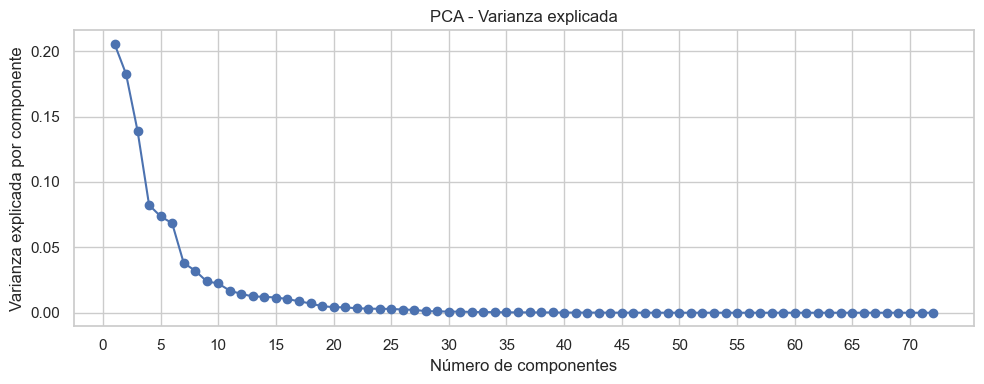

In [60]:
# PCA sobre las features numéricas estandarizadas.
X_tr_pca = X_train_std.select_dtypes(include=[np.number]).fillna(0)
X_te_pca = X_test_std.select_dtypes(include=[np.number]).fillna(0)
X_te_pca = X_te_pca[X_tr_pca.columns]

pca_full = PCA().fit(X_tr_pca)
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
componentes = np.arange(1, len(explained_var) + 1)

# varianza explicada por cada componente
plt.figure(figsize=(10, 4))
plt.plot(componentes, explained_var, marker='o')
plt.xticks(np.arange(0, len(componentes) + 1, 5))
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada por componente')
plt.title('PCA - Varianza explicada')
plt.grid(True)
plt.tight_layout()
plt.show()

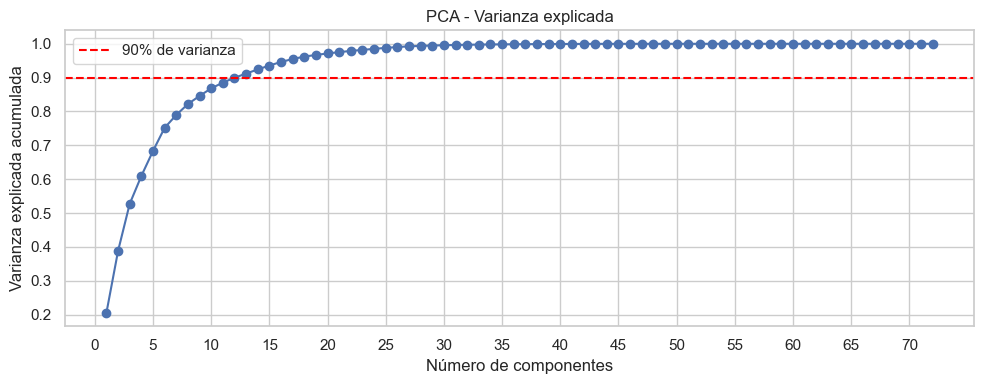

In [61]:
plt.figure(figsize=(10, 4))
plt.plot(componentes, cumulative_var, marker='o')
plt.xticks(np.arange(0, len(componentes) + 1, 5))
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA - Varianza explicada')
plt.grid(True)
plt.axhline(y=0.9, color='red', linestyle='--', label='90% de varianza')
plt.legend()
plt.tight_layout()
plt.show()


In [62]:
pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_tr_pca)
X_test_pca  = pca.transform(X_te_pca)

print(f'Componentes para retener 90% de varianza: {pca.n_components_}')
print(f'X_train_pca: {X_train_pca.shape} | X_test_pca: {X_test_pca.shape}')


Componentes para retener 90% de varianza: 13
X_train_pca: (188754, 13) | X_test_pca: (47189, 13)


In [63]:
# Loadings (cargas) de los primeros 5 componentes
loadings = pd.DataFrame(
    pca.components_[:5].T,
    columns=[f'PC{i+1}' for i in range(5)],
    index=X_tr_pca.columns,
)
# Top contribuciones por componente (en valor absoluto)
for c in loadings.columns:
    top5 = loadings[c].abs().sort_values(ascending=False).head(5).index
    print(f'\n{c} — top contribuciones:')
    print(loadings.loc[top5, c].round(3))



PC1 — top contribuciones:
month            -0.574
day_of_year      -0.573
quarter          -0.568
Community Area    0.073
Beat              0.069
Name: PC1, dtype: float64

PC2 — top contribuciones:
Community Area    0.488
Ward              0.451
Beat              0.446
Longitude        -0.429
Latitude          0.293
Name: PC2, dtype: float64

PC3 — top contribuciones:
Latitude          0.553
District          0.535
Beat             -0.315
Community Area   -0.311
Ward             -0.291
Name: PC3, dtype: float64

PC4 — top contribuciones:
distancia_cbd    0.823
Longitude       -0.355
District         0.305
Latitude        -0.215
hour            -0.169
Name: PC4, dtype: float64

PC5 — top contribuciones:
hour            -0.830
day_of_week      0.487
is_night         0.200
distancia_cbd   -0.148
night_violent    0.067
Name: PC5, dtype: float64


---
## 11. Conclusiones finales
### Resumen de impacto dimensional

In [64]:
resumen = pd.DataFrame([
    ['1. Dataset inicial enriquecido (post-merge)',     df_chicago.shape[1]],
    ['2. Tras limpieza general',                df_clean.shape[1] - 1],  # -1 por el target
    ['6. Tras codificación (OHE + TE)',         X_train.shape[1]],
    ['7. Tras escalado (std, solo numéricas)', len(num_cols_std)],
    ['8. Tras SMOTE (train balanceado)',        X_train_bal.shape[1]],
    ['9. Tras SelectKBest (top-K por MI)',      X_train_kbest.shape[1]],
    ['10. Tras PCA (95% varianza)',             pca.n_components_],
], columns=['Etapa', 'Nº features'])
resumen


,Etapa,Nº features
0,1. Dataset inicial enriquecido (post-merge),26
1,2. Tras limpieza general,10
2,6. Tras codificación (OHE + TE),72
3,"7. Tras escalado (std, solo numéricas)",72
4,8. Tras SMOTE (train balanceado),72
5,9. Tras SelectKBest (top-K por MI),20
6,10. Tras PCA (95% varianza),13


### Resumen del trabajo realizado
Seleccion de features
* Eliminar:
    * ID, case number, IUCR. Son IDs que no tienen aporte predictivo
    * Year es constante, es todo 2025
    * Location, porque es un punto que sale de Latitude/Longitude
    * Updated on, es in timestamp de actualization del registro
    * Coordenadas X/Y son lo mismo que latitud y longitud en otro sistema de referencia (State Plane Illinois East NAD 1983)
    * Location description, description y community area description porque tienen muy alta cardinalidad
    * Block es la dirección completa, reemplazable por Beat y District
    * IUCR primary, secondary y index code (4% nulos) que fueron agregados en el merge los sacamos

Duplicados
* 740 filas duplicadas al borrar los IDs

Split test/train
* Hay que usar stratify, porque la clase positiva ronda el 16%
    * Hace que la proporción de clases en el training set y el test set sea similares
* Test size: 20%
    * Train: 188754 registros
    * Test: 47189 registros

Tratamiento de faltantes
* Community Area, ward: se eliminan porque son solo 3 registros
* Latitude, longitude: usamos la mediana. Son solo 91 de 236k
    * La mediana es robusta a outliers. Chicago tiene zonas periféricas (aeropuertos, límites norte/sur) que estiran la media hacia los extremos.
    * Con mediana, un crimen sin coords "cae" en el centro geográfico típico de los crímenes, una suposición razonable cuando no sabemos nada más.
    * La media podría mover artificialmente el centroide si hubiera clusters de crímenes lejos del centro urbano. 

Manejo de outliers
* Como los outlier son valores legítimos en Longitud, decidimos no hacer nada

Feature engineering
* Date, a hour, day_of_week, month, quarter, day_of_year, is_night
    * Convertimos la fecha en algo que el modelo puede entender y usar
* distancia_cbd — distancia de Haversine (km) al Loop de Chicago (41.8827, -87.6227)
    * Captura el gradiente urbano centro-periferia, correlacionable con tipo de crimen y tasa de arresto
* is_violent + night_violent
    * is_violent: flag de crimen violento (HOMICIDE, ASSAULT, BATTERY, ROBBERY, CRIM/CRIMINAL SEXUAL ASSAULT, KIDNAPPING)
    * night_violent: interacción binaria is_night × is_violent — el crimen violento nocturno tiene un perfil operativo distinto (menor visibilidad, respuesta policial diferente) que ninguna flag captura sola

Codificacion
* Categorical
    * Cast a int
        * Domestic: es un boolean
    * One hot encoder
        * FBI code: 25 categorías
        * Primary type: 31 categorías
    * Target encoder
        * Ward: 50 categorias
        * Community Area: 77 categorias
        * Beat: 274 categorías

Escalado
* Standard scaler sobre latitude, longitude, distancia_cbd, beat, community area, ward, district, y las features temporales creadas sobre date (hour, day_of_week, month, quarter, day_of_year)
* is_night, is_violent, night_violent y Domestic quedan como binarias 0/1 sin escalar siguiendo el mismo criterio que las columnas OHE

Balanceo
* Usamos oversampling con SMOTE, porque undersampling haría que perdamos muchos datos valiosos

Seleccion de features por filtros
* Person/Spearman/Kendall
    * Vemos que month y quarter tienen una correlación alta con day_of_year por lo que son 2 features candidatas a eliminarse
* Información mutua
    * Nos podríamos quedar con el top 20 features con mayor información mutua contra la target para reducir la cantidad de features  

Extraccion de features:
* PCA
    * Con 13 componentes de los 72 retemos el 90% de la varianza